In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
RAW_DIR = "/content/drive/MyDrive/dataset"
OUT_DIR = "/content/drive/MyDrive/dataset/processed"
os.makedirs(OUT_DIR, exist_ok=True)

TRAJECTORIES = ["hover", "line", "square", "triangle"]

def inspect_file(path):
    df = pd.read_csv(path)
    print(f"\n--- {os.path.basename(path)} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    if "timestamp" in df.columns:
        ts = df["timestamp"].values
        duration_sec = (ts[-1] - ts[0]) / 1e6
        rate = len(df) / duration_sec if duration_sec > 0 else 0
        print(f"Duration: {duration_sec:.1f}s | Sample rate: {rate:.1f} Hz")
    print(df.head(2))

for traj in TRAJECTORIES:
    for suffix in ["", "_imu", "_imu_status"]:
        path = f"{RAW_DIR}/normal_{traj}{suffix}.csv"
        if os.path.exists(path):
            inspect_file(path)
        else:
            print(f"MISSING: {path}")



--- normal_hover.csv ---
Shape: (1725, 37)
Columns: ['timestamp', 'timestamp_sample', 'latitude_deg', 'longitude_deg', 'altitude_msl_m', 'altitude_ellipsoid_m', 'time_utc_usec', 'device_id', 's_variance_m_s', 'c_variance_rad', 'eph', 'epv', 'hdop', 'vdop', 'noise_per_ms', 'jamming_indicator', 'vel_m_s', 'vel_n_m_s', 'vel_e_m_s', 'vel_d_m_s', 'cog_rad', 'timestamp_time_relative', 'system_error', 'heading', 'heading_offset', 'heading_accuracy', 'rtcm_injection_rate', 'automatic_gain_control', 'fix_type', 'jamming_state', 'spoofing_state', 'authentication_state', 'vel_ned_valid', 'satellites_used', 'selected_rtcm_instance', 'rtcm_crc_failed', 'rtcm_msg_used']
Duration: 680.8s | Sample rate: 2.5 Hz
     timestamp  timestamp_sample  latitude_deg  longitude_deg  altitude_msl_m  \
0  10459048000       10459048000      47.39775       8.545607         488.112   
1  10459448000       10459448000      47.39775       8.545607         488.106   

   altitude_ellipsoid_m  time_utc_usec  device_id  

In [ ]:
GPS_COLS = {

    "lat":   "latitude_deg",
    "lon":   "longitude_deg",
    "alt":   "altitude_msl_m",
    "vel_n": "vel_n_m_s",
    "vel_e": "vel_e_m_s",
    "vel_d": "vel_d_m_s",
}

IMU_COLS = {
    "dvel_x": "delta_velocity[0]",
    "dvel_y": "delta_velocity[1]",
    "dvel_z": "delta_velocity[2]",
    "dang_x": "delta_angle[0]",
    "dang_y": "delta_angle[1]",
    "dang_z": "delta_angle[2]",
}

IMU_STATUS_COLS = {}


In [ ]:
def load_and_rename(path, col_map):
    """Load a CSV and keep only the columns we want, renamed to standard names."""
    df = pd.read_csv(path)
    keep = {old: new for new, old in col_map.items() if old in df.columns}
    missing = [old for new, old in col_map.items() if old not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {path}: {missing}\nAvailable: {list(df.columns)}")
    df = df[["timestamp"] + list(keep.keys())].rename(columns=keep)
    return df.sort_values("timestamp").reset_index(drop=True)


def merge_trajectory(traj_name):
    """Load GPS + IMU for one trajectory and align them by timestamp."""
    gps_path = f"{RAW_DIR}/normal_{traj_name}.csv"
    imu_path = f"{RAW_DIR}/normal_{traj_name}_imu.csv"

    gps = load_and_rename(gps_path, GPS_COLS)
    imu = load_and_rename(imu_path, IMU_COLS)

    print(f"\n[{traj_name}] GPS: {len(gps)} rows | IMU: {len(imu)} rows")

    merged = pd.merge_asof(
        gps, imu,
        on="timestamp",
        direction="nearest",
        tolerance=500_000
    )

    before = len(merged)
    merged = merged.dropna().reset_index(drop=True)
    print(f"[{traj_name}] After alignment: {len(merged)} rows (dropped {before - len(merged)})")

    return merged


# test on one trajectory first
test_df = merge_trajectory("hover")
print("\nMerged columns:", list(test_df.columns))
print(test_df.head())



[hover] GPS: 1725 rows | IMU: 1361 rows
[hover] After alignment: 1724 rows (dropped 1)

Merged columns: ['timestamp', 'lat', 'lon', 'alt', 'vel_n', 'vel_e', 'vel_d', 'dvel_x', 'dvel_y', 'dvel_z', 'dang_x', 'dang_y', 'dang_z']
     timestamp       lat       lon      alt  vel_n  vel_e  vel_d    dvel_x  \
0  10459448000  47.39775  8.545607  488.106   0.00   0.01  -0.02  0.000431   
1  10459848000  47.39775  8.545607  488.113   0.01   0.00   0.01  0.000431   
2  10460248000  47.39775  8.545607  488.110   0.00   0.00   0.00  0.000373   
3  10460648000  47.39775  8.545607  488.103   0.01   0.00  -0.04 -0.000024   
4  10461044000  47.39775  8.545607  488.099  -0.02   0.01  -0.01  0.000273   

     dvel_y    dvel_z    dang_x    dang_y    dang_z  
0  0.000029 -0.039509  0.000012  0.000013  0.000009  
1  0.000029 -0.039509  0.000012  0.000013  0.000009  
2  0.000263 -0.039385 -0.000036 -0.000011 -0.000017  
3  0.000426 -0.039059  0.000062 -0.000045 -0.000013  
4 -0.000010 -0.039207  0.000010 -0

In [ ]:
all_normal = []
for traj in TRAJECTORIES:
    df = merge_trajectory(traj)
    df["flight_id"] = f"normal_{traj}"
    df["trajectory"] = traj
    df["label"] = 0  # all normal data
    all_normal.append(df)

normal_master = pd.concat(all_normal, ignore_index=True)
print(f"\nMaster normal dataset: {normal_master.shape}")
print(f"Per-trajectory counts:\n{normal_master['flight_id'].value_counts()}")

normal_master.to_csv(f"{OUT_DIR}/normal_master.csv", index=False)
print(f"Saved to {OUT_DIR}/normal_master.csv")



[hover] GPS: 1725 rows | IMU: 1361 rows
[hover] After alignment: 1724 rows (dropped 1)

[line] GPS: 10699 rows | IMU: 8413 rows
[line] After alignment: 10698 rows (dropped 1)

[square] GPS: 6820 rows | IMU: 5388 rows
[square] After alignment: 6820 rows (dropped 0)

[triangle] GPS: 3076 rows | IMU: 2430 rows
[triangle] After alignment: 3075 rows (dropped 1)

Master normal dataset: (22317, 16)
Per-trajectory counts:
flight_id
normal_line        10698
normal_square       6820
normal_triangle     3075
normal_hover        1724
Name: count, dtype: int64
Saved to /content/drive/MyDrive/dataset/processed/normal_master.csv


In [ ]:
def inject_spoofing(df, drift_axis, drift_rate, start_frac=0.5, sample_rate_hz=10):

    spoofed = df.copy().reset_index(drop=True)
    n = len(spoofed)
    start_idx = int(n * start_frac)

    # convert lat/lon degrees per meter (rough, at equator)
    DEG_PER_M_LAT = 1 / 111_320
    DEG_PER_M_LON = 1 / 111_320
    dt = 1.0 / sample_rate_hz

    # position offset over time
    cumulative_offset = {"lat": 0.0, "lon": 0.0, "alt": 0.0,
                         "vel_n": 0.0, "vel_e": 0.0, "vel_d": 0.0}

    label = np.zeros(n, dtype=np.int32)

    for i in range(start_idx, n):
        # update velocity injection
        for axis, magnitude in drift_axis.items():
            full_drift = magnitude * drift_rate
            if axis == "vel_n":
                spoofed.loc[i, "vel_n"] = df.loc[i, "vel_n"] + full_drift
                cumulative_offset["lat"] += full_drift * dt * DEG_PER_M_LAT
                spoofed.loc[i, "lat"] = df.loc[i, "lat"] + cumulative_offset["lat"]
            elif axis == "vel_e":
                spoofed.loc[i, "vel_e"] = df.loc[i, "vel_e"] + full_drift
                cumulative_offset["lon"] += full_drift * dt * DEG_PER_M_LON
                spoofed.loc[i, "lon"] = df.loc[i, "lon"] + cumulative_offset["lon"]
            elif axis == "vel_d":
                spoofed.loc[i, "vel_d"] = df.loc[i, "vel_d"] + full_drift
                cumulative_offset["alt"] -= full_drift * dt  # vel_d positive = down
                spoofed.loc[i, "alt"] = df.loc[i, "alt"] + cumulative_offset["alt"]
        label[i] = 1

    spoofed["label"] = label
    return spoofed

In [ ]:
#spoofed variants
MAGNITUDES = [0.1, 0.2, 0.5, 1.0]   # m/s

DIRECTIONS = {
    "N":   {"vel_n": 1.0},
    "E":   {"vel_e": 1.0},
    "Up":  {"vel_d": -1.0},
    "NE":  {"vel_n": 0.707, "vel_e": 0.707},
    "NEU": {"vel_n": 0.577, "vel_e": 0.577, "vel_d": -0.577},
}

ONSETS = [0.0, 0.25, 0.50, 0.75]

sample_rate = 2.5

spoofed_files = []

print("\n=== Block 1: Magnitude sweep ===")
for traj in TRAJECTORIES:
    base = normal_master[normal_master["trajectory"] == traj].reset_index(drop=True)
    for mag in MAGNITUDES:
        spoofed = inject_spoofing(base, {"vel_n": 1.0}, mag,
                                   start_frac=0.5, sample_rate_hz=sample_rate)
        spoofed["flight_id"] = f"spoof_{traj}_magN{mag}"
        spoofed["trajectory"] = traj
        spoofed_files.append(spoofed)
        print(f"  {spoofed['flight_id'].iloc[0]}: {len(spoofed)} rows, "
              f"{spoofed['label'].sum()} spoofed timesteps")

print("\n=== Block 2: Direction variation ===")
for traj in TRAJECTORIES:
    base = normal_master[normal_master["trajectory"] == traj].reset_index(drop=True)
    for dir_name, dir_vec in DIRECTIONS.items():
        spoofed = inject_spoofing(base, dir_vec, 0.3,
                                   start_frac=0.5, sample_rate_hz=sample_rate)
        spoofed["flight_id"] = f"spoof_{traj}_dir{dir_name}"
        spoofed["trajectory"] = traj
        spoofed_files.append(spoofed)
        print(f"  {spoofed['flight_id'].iloc[0]}: {len(spoofed)} rows")

print("\n=== Block 3: Onset timing ===")
for traj in TRAJECTORIES:
    base = normal_master[normal_master["trajectory"] == traj].reset_index(drop=True)
    for onset in ONSETS:
        spoofed = inject_spoofing(base, {"vel_n": 1.0}, 0.3,
                                   start_frac=onset, sample_rate_hz=sample_rate)
        spoofed["flight_id"] = f"spoof_{traj}_onset{int(onset*100)}"
        spoofed["trajectory"] = traj
        spoofed_files.append(spoofed)
        print(f"  {spoofed['flight_id'].iloc[0]}: {len(spoofed)} rows")

print(f"\nTotal spoofed files generated: {len(spoofed_files)}")


=== Block 1: Magnitude sweep ===
  spoof_hover_magN0.1: 1724 rows, 862 spoofed timesteps
  spoof_hover_magN0.2: 1724 rows, 862 spoofed timesteps
  spoof_hover_magN0.5: 1724 rows, 862 spoofed timesteps
  spoof_hover_magN1.0: 1724 rows, 862 spoofed timesteps
  spoof_line_magN0.1: 10698 rows, 5349 spoofed timesteps
  spoof_line_magN0.2: 10698 rows, 5349 spoofed timesteps
  spoof_line_magN0.5: 10698 rows, 5349 spoofed timesteps
  spoof_line_magN1.0: 10698 rows, 5349 spoofed timesteps
  spoof_square_magN0.1: 6820 rows, 3410 spoofed timesteps
  spoof_square_magN0.2: 6820 rows, 3410 spoofed timesteps
  spoof_square_magN0.5: 6820 rows, 3410 spoofed timesteps
  spoof_square_magN1.0: 6820 rows, 3410 spoofed timesteps
  spoof_triangle_magN0.1: 3075 rows, 1538 spoofed timesteps
  spoof_triangle_magN0.2: 3075 rows, 1538 spoofed timesteps
  spoof_triangle_magN0.5: 3075 rows, 1538 spoofed timesteps
  spoof_triangle_magN1.0: 3075 rows, 1538 spoofed timesteps

=== Block 2: Direction variation ===
  sp

In [ ]:
all_data = [normal_master] + spoofed_files
final = pd.concat(all_data, ignore_index=True)

print(f"\nFinal dataset shape: {final.shape}")
print(f"Class balance:\n{final['label'].value_counts(normalize=True)}")
print(f"Total flights: {final['flight_id'].nunique()}")
print(f"  Normal: {final[final['label']==0]['flight_id'].nunique()}")
print(f"  Spoofed: {final[final['flight_id'].str.startswith('spoof')]['flight_id'].nunique()}")

final.to_csv(f"{OUT_DIR}/final_dataset.csv", index=False)
print(f"\nSaved to {OUT_DIR}/final_dataset.csv")


Final dataset shape: (312438, 16)
Class balance:
label
1    0.500022
0    0.499978
Name: proportion, dtype: float64
Total flights: 56
  Normal: 52
  Spoofed: 52

Saved to /content/drive/MyDrive/dataset/processed/final_dataset.csv


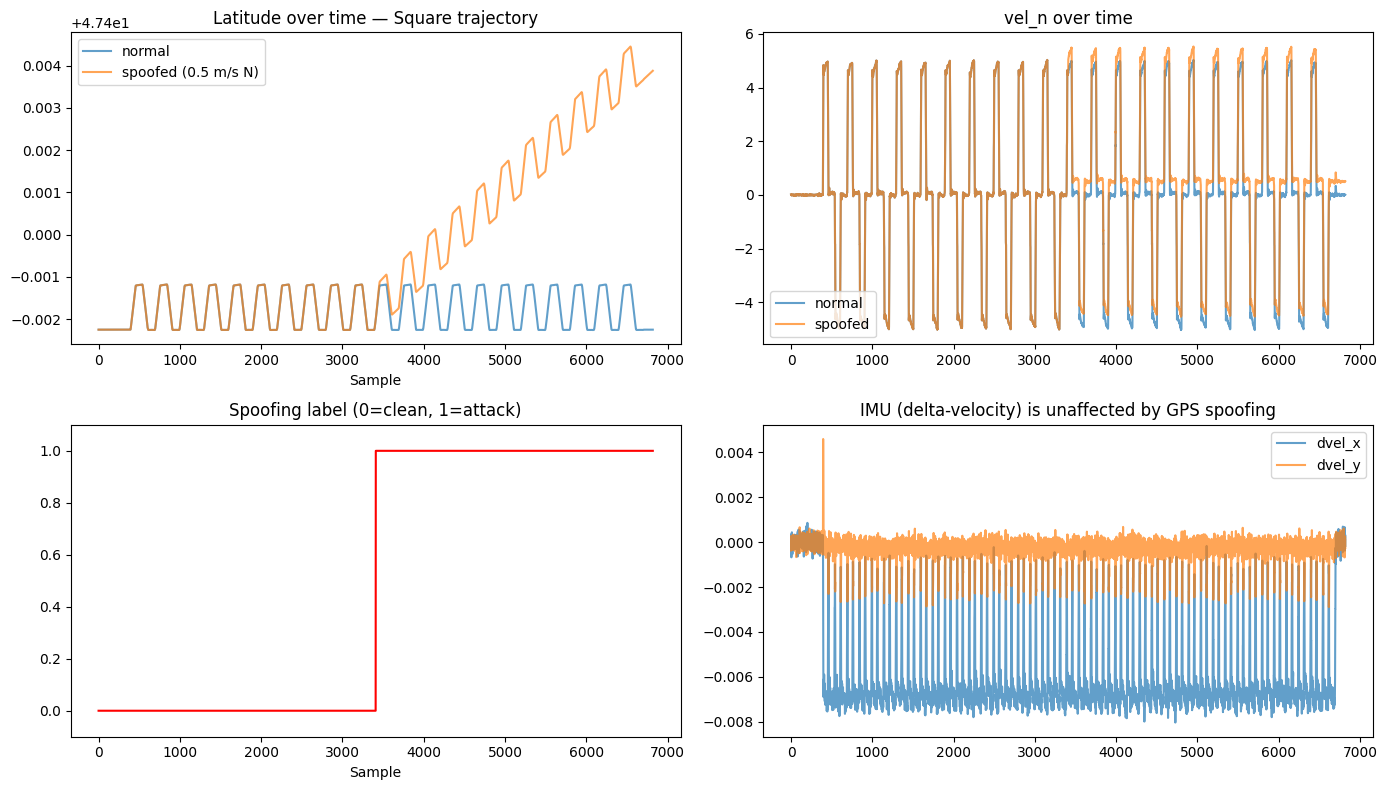


Sanity check plot saved to /content/drive/MyDrive/dataset/processed/sanity_check.png
Look for: latitude diverges from normal after sample ~50% of flight, while accelerometer stays unchanged. That's the spoofing signature.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

normal_sq = final[final["flight_id"] == "normal_square"]
spoof_sq = final[final["flight_id"] == "spoof_square_magN0.5"]

axes[0, 0].plot(normal_sq["lat"].values, label="normal", alpha=0.7)
axes[0, 0].plot(spoof_sq["lat"].values, label="spoofed (0.5 m/s N)", alpha=0.7)
axes[0, 0].set_title("Latitude over time — Square trajectory")
axes[0, 0].legend()
axes[0, 0].set_xlabel("Sample")

axes[0, 1].plot(normal_sq["vel_n"].values, label="normal", alpha=0.7)
axes[0, 1].plot(spoof_sq["vel_n"].values, label="spoofed", alpha=0.7)
axes[0, 1].set_title("vel_n over time")
axes[0, 1].legend()

axes[1, 0].plot(spoof_sq["label"].values, color="red")
axes[1, 0].set_title("Spoofing label (0=clean, 1=attack)")
axes[1, 0].set_xlabel("Sample")
axes[1, 0].set_ylim(-0.1, 1.1)

axes[1, 1].plot(spoof_sq["dvel_x"].values, label="dvel_x", alpha=0.7)
axes[1, 1].plot(spoof_sq["dvel_y"].values, label="dvel_y", alpha=0.7)
axes[1, 1].set_title("IMU (delta-velocity) is unaffected by GPS spoofing")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sanity_check.png", dpi=100)
plt.show()
print(f"\nSanity check plot saved to {OUT_DIR}/sanity_check.png")
print("Look for: latitude diverges from normal after sample ~50% of flight, "
      "while accelerometer stays unchanged. That's the spoofing signature.")


In [ ]:
%cd /content/drive/MyDrive/dataset/processed
%run fyp2_fixed_v3.py

/content/drive/MyDrive/dataset/processed

RUNNING SEED = 42
Loaded 312438 rows, 16 columns
Unique flights: 56
Feature columns (12): ['lat', 'lon', 'alt', 'vel_n', 'vel_e', 'vel_d', 'dvel_x', 'dvel_y', 'dvel_z', 'dang_x', 'dang_y', 'dang_z']

Building sequences per flight...
Built 309582 sequence samples from 56 flights
Overall class balance: [153560 156022]

Split by FLIGHT:
  Train: 40 flights
  Val:   6 flights -> [np.str_('spoof_hover_dirE'), np.str_('spoof_hover_dirUp'), np.str_('spoof_hover_onset50'), np.str_('spoof_square_magN0.2'), np.str_('spoof_square_magN0.5'), np.str_('spoof_triangle_onset25')]
  Test:  10 flights -> [np.str_('spoof_hover_onset75'), np.str_('spoof_line_dirE'), np.str_('spoof_line_magN0.5'), np.str_('spoof_line_onset50'), np.str_('spoof_square_dirNEU'), np.str_('spoof_square_dirUp'), np.str_('spoof_square_magN1.0'), np.str_('spoof_square_onset0'), np.str_('spoof_triangle_dirUp'), np.str_('spoof_triangle_magN1.0')]

Sample counts:
  Train: 221263 | class balan

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM predictor: training on 113507 normal samples
Epoch 1/15
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 158s 88ms/step - loss: 0.0478 - val_loss: 0.0084
Epoch 2/15
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 203s 88ms/step - loss: 0.0311 - val_loss: 0.0086
Epoch 3/15
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 160s 90ms/step - loss: 0.0294 - val_loss: 0.0122
Epoch 4/15
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 160s 90ms/step - loss: 0.0286 - val_loss: 0.0056
Epoch 5/15
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 157s 89ms/step - loss: 0.0278 - val_loss: 0.0061
Epoch 6/15
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 158s 89ms/step - loss: 0.0269 - val_loss: 0.0054
Epoch 7/15
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 160s 90ms/step - loss: 0.0264 - val_loss: 0.0056
Epoch 8/15
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 200s 89ms/step - loss: 0.0257 - val_loss: 0.0065
Epoch 9/15
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 157s 88ms/step - loss: 0.0257 - val_loss: 0.0081
Epoch 10/15
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 160s 90ms/step - loss: 0.0261 - val_loss: 0.0076

Best fusion params (on val): w=0.00, t

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
3458/3458 ━━━━━━━━━━━━━━━━━━━━ 312s 89ms/step - accuracy: 0.9467 - loss: 0.1589 - val_accuracy: 0.9418 - val_loss: 0.2019
Epoch 2/15
3458/3458 ━━━━━━━━━━━━━━━━━━━━ 320s 93ms/step - accuracy: 0.9680 - loss: 0.1091 - val_accuracy: 0.9483 - val_loss: 0.2119
Epoch 3/15
3458/3458 ━━━━━━━━━━━━━━━━━━━━ 326s 94ms/step - accuracy: 0.9752 - loss: 0.0870 - val_accuracy: 0.9443 - val_loss: 0.2046
Epoch 4/15
3458/3458 ━━━━━━━━━━━━━━━━━━━━ 373s 92ms/step - accuracy: 0.9826 - loss: 0.0602 - val_accuracy: 0.9530 - val_loss: 0.1992
Epoch 5/15
3458/3458 ━━━━━━━━━━━━━━━━━━━━ 309s 89ms/step - accuracy: 0.9870 - loss: 0.0445 - val_accuracy: 0.9530 - val_loss: 0.1926
Epoch 6/15
3458/3458 ━━━━━━━━━━━━━━━━━━━━ 305s 88ms/step - accuracy: 0.9885 - loss: 0.0394 - val_accuracy: 0.9771 - val_loss: 0.0855
Epoch 7/15
3458/3458 ━━━━━━━━━━━━━━━━━━━━ 315s 91ms/step - accuracy: 0.9895 - loss: 0.0358 - val_accuracy: 0.9567 - val_loss: 0.1216
Epoch 8/15
3458/3458 ━━━━━━━━━━━━━━━━━━━━ 302s 87ms/step - accuracy: 

...

Epoch 1/15
3439/3439 ━━━━━━━━━━━━━━━━━━━━ 315s 91ms/step - accuracy: 0.9516 - loss: 0.1449 - val_accuracy: 0.9442 - val_loss: 0.1662
Epoch 2/15
3439/3439 ━━━━━━━━━━━━━━━━━━━━ 328s 95ms/step - accuracy: 0.9746 - loss: 0.0859 - val_accuracy: 0.9637 - val_loss: 0.1156
Epoch 3/15
3439/3439 ━━━━━━━━━━━━━━━━━━━━ 323s 94ms/step - accuracy: 0.9830 - loss: 0.0591 - val_accuracy: 0.9557 - val_loss: 0.1542
Epoch 4/15
3439/3439 ━━━━━━━━━━━━━━━━━━━━ 311s 91ms/step - accuracy: 0.9883 - loss: 0.0395 - val_accuracy: 0.9741 - val_loss: 0.0881
Epoch 5/15
3439/3439 ━━━━━━━━━━━━━━━━━━━━ 325s 95ms/step - accuracy: 0.9904 - loss: 0.0317 - val_accuracy: 0.9757 - val_loss: 0.1005
Epoch 6/15
3439/3439 ━━━━━━━━━━━━━━━━━━━━ 324s 94ms/step - accuracy: 0.9916 - loss: 0.0273 - val_accuracy: 0.9729 - val_loss: 0.1021
Epoch 7/15
3439/3439 ━━━━━━━━━━━━━━━━━━━━ 331s 96ms/step - accuracy: 0.9927 - loss: 0.0233 - val_accuracy: 0.9508 - val_loss: 0.1500
Epoch 8/15
3439/3439 ━━━━━━━━━━━━━━━━━━━━ 326s 95ms/step - accuracy: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM predictor: training on 113768 normal samples
Epoch 1/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 174s 95ms/step - loss: 0.0454 - val_loss: 0.0125
Epoch 2/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 168s 94ms/step - loss: 0.0306 - val_loss: 0.0078
Epoch 3/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 162s 91ms/step - loss: 0.0285 - val_loss: 0.0099
Epoch 4/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 171s 96ms/step - loss: 0.0278 - val_loss: 0.0086
Epoch 5/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 193s 91ms/step - loss: 0.0270 - val_loss: 0.0084
Epoch 6/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 202s 91ms/step - loss: 0.0262 - val_loss: 0.0065
Epoch 7/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 160s 90ms/step - loss: 0.0261 - val_loss: 0.0063
Epoch 8/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 156s 88ms/step - loss: 0.0256 - val_loss: 0.0060
Epoch 9/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 161s 90ms/step - loss: 0.0252 - val_loss: 0.0063
Epoch 10/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 159s 89ms/step - loss: 0.0253 - val_loss: 0.0054
Epoch 11/15
1778/1778 ━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
3456/3456 ━━━━━━━━━━━━━━━━━━━━ 334s 96ms/step - accuracy: 0.9447 - loss: 0.1688 - val_accuracy: 0.9722 - val_loss: 0.1025
Epoch 2/15
3456/3456 ━━━━━━━━━━━━━━━━━━━━ 327s 95ms/step - accuracy: 0.9768 - loss: 0.0846 - val_accuracy: 0.9610 - val_loss: 0.1537
Epoch 3/15
3456/3456 ━━━━━━━━━━━━━━━━━━━━ 371s 91ms/step - accuracy: 0.9834 - loss: 0.0593 - val_accuracy: 0.9869 - val_loss: 0.0466
Epoch 4/15
3456/3456 ━━━━━━━━━━━━━━━━━━━━ 311s 90ms/step - accuracy: 0.9877 - loss: 0.0432 - val_accuracy: 0.9882 - val_loss: 0.0423
Epoch 5/15
3456/3456 ━━━━━━━━━━━━━━━━━━━━ 321s 89ms/step - accuracy: 0.9908 - loss: 0.0321 - val_accuracy: 0.9872 - val_loss: 0.0415
Epoch 6/15
3456/3456 ━━━━━━━━━━━━━━━━━━━━ 326s 91ms/step - accuracy: 0.9903 - loss: 0.0340 - val_accuracy: 0.9834 - val_loss: 0.0478
Epoch 7/15
3456/3456 ━━━━━━━━━━━━━━━━━━━━ 328s 92ms/step - accuracy: 0.9928 - loss: 0.0237 - val_accuracy: 0.9904 - val_loss: 0.0352
Epoch 8/15
3456/3456 ━━━━━━━━━━━━━━━━━━━━ 312s 90ms/step - accuracy: 

In [ ]:
%cd /content/drive/MyDrive/dataset/processed
%run pathB_analysis.py

/content/drive/MyDrive/dataset/processed
PATH B ANALYSIS — early detection (B1) + early-window eval (B3)
Loaded /content/drive/MyDrive/dataset/processed/predictions_seed123.json -> models: ['HYBRID', 'ABLATION']
Loaded /content/drive/MyDrive/dataset/processed/predictions_seed42.json -> models: ['HYBRID', 'ABLATION']
Loaded /content/drive/MyDrive/dataset/processed/predictions_seed456.json -> models: ['HYBRID', 'ABLATION']

B1: DETECTION LATENCY (samples from attack onset to first alarm)

Per-model detection latency (across all seeds & flights):
   model  mean_delay_samples  median_delay_samples  std_delay_samples  mean_delay_sec  detection_rate  n_flights
ABLATION           13.800000                   0.0          64.627527        5.520000             1.0         30
  HYBRID            6.066667                   0.0          25.304945        2.426667             1.0         30

Per-model x per-trajectory mean detection delay (samples):
model        ABLATION     HYBRID
trajectory        

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/dataset/processed/final_dataset.csv")

# pick one spoofed flight
fl = df[df["flight_id"] == "spoof_square_magN0.5"].reset_index(drop=True)

# find the onset and show rows around it
onset = fl[fl["label"] == 1].index[0]
print(f"Attack onset at row {onset}")
print(fl.iloc[onset-3:onset+4][["lat","lon","vel_n","vel_e","dvel_x","dvel_y","label"]])

Attack onset at row 3410
            lat       lon  vel_n  vel_e    dvel_x    dvel_y  label
3407  47.397948  8.545605   4.49   0.00 -0.006589 -0.000101      0
3408  47.397965  8.545605   4.51   0.02 -0.006555 -0.000417      0
3409  47.397981  8.545606   4.56   0.02 -0.006680 -0.000201      0
3410  47.397991  8.545606   5.04   0.02 -0.006680 -0.000201      1
3411  47.398009  8.545606   5.05   0.03 -0.006407 -0.000464      1
3412  47.398027  8.545606   5.07   0.03 -0.006833 -0.000464      1
3413  47.398046  8.545606   5.09   0.01 -0.006728 -0.000268      1
